In [58]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/data/variants_demo.tsv", sep="\t")

df.head()

,variant_id,gene,chrom,pos,ref,alt,consequence,impact,allele_freq
0,var1,TP53,17,7676153,C,T,missense_variant,MODERATE,0.0012
1,var2,BRCA1,17,43045729,A,G,stop_gained,HIGH,0.0001
2,var3,EGFR,7,55249071,G,A,synonymous_variant,LOW,0.0120
3,var4,CFTR,7,117559593,T,C,splice_region_variant,MODERATE,0.0008
4,var5,HBB,11,5227002,A,T,missense_variant,MODERATE,0.0045


In [59]:
df["score"] = df.apply(score_variant, axis=1)

df.sort_values("score", ascending=False).head(10)

,variant_id,gene,chrom,pos,ref,alt,consequence,impact,allele_freq,score
1,var2,BRCA1,17,43045729,A,G,stop_gained,HIGH,0.0001,8
8,var9,PCSK9,1,55505647,G,A,stop_gained,HIGH,0.0002,8
9,var10,LMNA,1,156084382,C,T,missense_variant,MODERATE,0.0006,5
3,var4,CFTR,7,117559593,T,C,splice_region_variant,MODERATE,0.0008,5
0,var1,TP53,17,7676153,C,T,missense_variant,MODERATE,0.0012,4
4,var5,HBB,11,5227002,A,T,missense_variant,MODERATE,0.0045,4
5,var6,KRAS,12,25245350,G,T,missense_variant,MODERATE,0.0021,4
7,var8,MTHFR,1,11856378,C,T,missense_variant,MODERATE,0.0820,3
6,var7,APOE,19,44908684,C,T,missense_variant,MODERATE,0.1450,3
2,var3,EGFR,7,55249071,G,A,synonymous_variant,LOW,0.0120,1


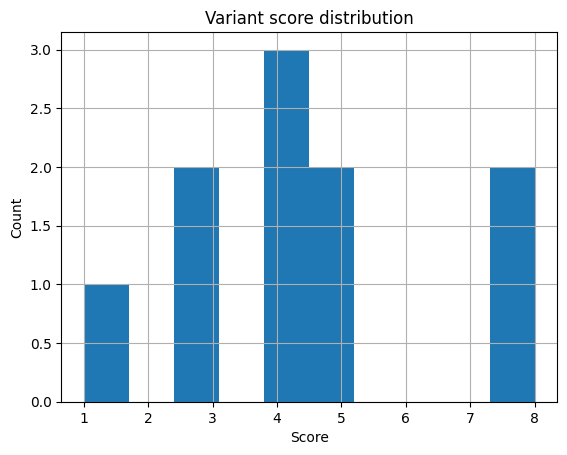

In [60]:
import matplotlib.pyplot as plt

df["score"].hist(bins=10)
plt.title("Variant score distribution")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()

import pandas as pd
import numpy as np

df = pd.read_csv("../data/variants_demo.tsv", sep="\t")

df.head()

In [61]:
impact_base = {
    "HIGH": 6,
    "MODERATE": 3,
    "LOW": 1
}

def score_variant(row):
    score = impact_base.get(row["impact"], 1)

    af = row["allele_freq"]

    if af < 1e-4:
        score += 3
    elif af < 1e-3:
        score += 2
    elif af < 1e-2:
        score += 1

    return score

In [62]:
df["score"] = df.apply(score_variant, axis=1)

df.sort_values("score", ascending=False).head(10)

,variant_id,gene,chrom,pos,ref,alt,consequence,impact,allele_freq,score
1,var2,BRCA1,17,43045729,A,G,stop_gained,HIGH,0.0001,8
8,var9,PCSK9,1,55505647,G,A,stop_gained,HIGH,0.0002,8
9,var10,LMNA,1,156084382,C,T,missense_variant,MODERATE,0.0006,5
3,var4,CFTR,7,117559593,T,C,splice_region_variant,MODERATE,0.0008,5
0,var1,TP53,17,7676153,C,T,missense_variant,MODERATE,0.0012,4
4,var5,HBB,11,5227002,A,T,missense_variant,MODERATE,0.0045,4
5,var6,KRAS,12,25245350,G,T,missense_variant,MODERATE,0.0021,4
7,var8,MTHFR,1,11856378,C,T,missense_variant,MODERATE,0.0820,3
6,var7,APOE,19,44908684,C,T,missense_variant,MODERATE,0.1450,3
2,var3,EGFR,7,55249071,G,A,synonymous_variant,LOW,0.0120,1


In [63]:
df["score"] = df.apply(score_variant, axis=1)

df.sort_values("score", ascending=False).head(10)

,variant_id,gene,chrom,pos,ref,alt,consequence,impact,allele_freq,score
1,var2,BRCA1,17,43045729,A,G,stop_gained,HIGH,0.0001,8
8,var9,PCSK9,1,55505647,G,A,stop_gained,HIGH,0.0002,8
9,var10,LMNA,1,156084382,C,T,missense_variant,MODERATE,0.0006,5
3,var4,CFTR,7,117559593,T,C,splice_region_variant,MODERATE,0.0008,5
0,var1,TP53,17,7676153,C,T,missense_variant,MODERATE,0.0012,4
4,var5,HBB,11,5227002,A,T,missense_variant,MODERATE,0.0045,4
5,var6,KRAS,12,25245350,G,T,missense_variant,MODERATE,0.0021,4
7,var8,MTHFR,1,11856378,C,T,missense_variant,MODERATE,0.0820,3
6,var7,APOE,19,44908684,C,T,missense_variant,MODERATE,0.1450,3
2,var3,EGFR,7,55249071,G,A,synonymous_variant,LOW,0.0120,1






### CRISPR target candidate prioritization

In [64]:
candidate_variants = df[
    (df["impact"] == "HIGH") &
    (df["allele_freq"] < 0.001)
]

candidate_variants[["variant_id","gene","impact","allele_freq","score"]]

,variant_id,gene,impact,allele_freq,score
1,var2,BRCA1,HIGH,0.0001,8
8,var9,PCSK9,HIGH,0.0002,8


### CRISPR target candidate prioritization

We prioritize variants that occur in genes commonly studied as potential CRISPR targets.
This step demonstrates how variant ranking can be combined with gene-level prioritization.

In [65]:
crispr_target_genes = {"BRCA1", "TP53", "CFTR", "PCSK9"}

df["crispr_target_candidate"] = df["gene"].isin(crispr_target_genes)

df.sort_values(
    ["crispr_target_candidate", "score"],
    ascending=[False, False]
)[
    ["variant_id", "gene", "consequence", "impact", "allele_freq", "score", "crispr_target_candidate"]
].head(10)

,variant_id,gene,consequence,impact,allele_freq,score,crispr_target_candidate
1,var2,BRCA1,stop_gained,HIGH,0.0001,8,True
8,var9,PCSK9,stop_gained,HIGH,0.0002,8,True
3,var4,CFTR,splice_region_variant,MODERATE,0.0008,5,True
0,var1,TP53,missense_variant,MODERATE,0.0012,4,True
9,var10,LMNA,missense_variant,MODERATE,0.0006,5,False
4,var5,HBB,missense_variant,MODERATE,0.0045,4,False
5,var6,KRAS,missense_variant,MODERATE,0.0021,4,False
6,var7,APOE,missense_variant,MODERATE,0.1450,3,False
7,var8,MTHFR,missense_variant,MODERATE,0.0820,3,False
2,var3,EGFR,synonymous_variant,LOW,0.0120,1,False


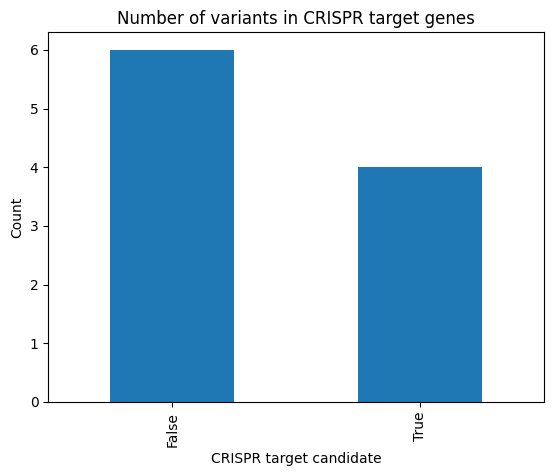

In [66]:
df["crispr_target_candidate"].value_counts().plot(kind="bar")
plt.title("Number of variants in CRISPR target genes")
plt.xlabel("CRISPR target candidate")
plt.ylabel("Count")
plt.show()

In [67]:
gene_summary = (
    df.groupby("gene")
      .agg(
          variant_count=("variant_id", "count"),
          mean_score=("score", "mean"),
          max_score=("score", "max")
      )
      .sort_values("mean_score", ascending=False)
)

gene_summary

,variant_count,mean_score,max_score
gene,,,
BRCA1,1,8.0,8
PCSK9,1,8.0,8
LMNA,1,5.0,5
CFTR,1,5.0,5
TP53,1,4.0,4
HBB,1,4.0,4
KRAS,1,4.0,4
APOE,1,3.0,3
MTHFR,1,3.0,3


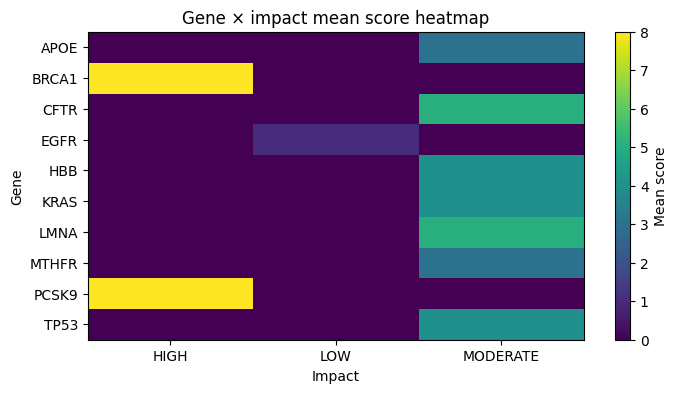

In [68]:
heatmap_data = pd.crosstab(df["gene"], df["impact"], values=df["score"], aggfunc="mean").fillna(0)

plt.figure(figsize=(8, 4))
plt.imshow(heatmap_data, aspect="auto")
plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns)
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)
plt.colorbar(label="Mean score")
plt.title("Gene × impact mean score heatmap")
plt.xlabel("Impact")
plt.ylabel("Gene")
plt.show()

### Interpretation

Variants with HIGH predicted impact and low allele frequency receive the highest prioritization scores in this demo.  
The CRISPR target candidate step further highlights variants in genes of potential interest for genome editing applications.  
This illustrates how variant-level scoring can be extended into simple gene-level prioritization.